## Лабораторна робота №4

**Виконали:**   
   
Варіант 2
- Сачек Владислава, КА-31
- Богданова Олександра, КА-32
- Плахтій Злата, КА-32

**Хід виконання роботи:**
1. Завантажити два набори зображень згiдно з варiантом: чорно-бiлi (дивiться попереднiй практикум) та кольоровi. Якщо набiр великого розмiру, можна обрати частину.
2. Пiдготувати данi для навчання - за необхiдностi.
3. Роздiлити данi на навчальну, перевiрочну i тестову пiдмножини.
4. Побудувати i навчити базову модель з одним згортковим шаром. Оцiнити правильнiсть (accuracy) та точнiсть моделi на тренувальнiй i перевiрочнiй множинах.
5. Дослiдити рiзнi значення параметрiв padding i strides згорткового шару базової моделi, а також розмiрнiсть ядра (kernel) згортки та їх вплив на точнiсть моделi. На перевiрочнiй множинi обрати значення вказаних параметрiв.
6. Дослiдити кiлька альтернативних архiтектур згорткових моделей, якi включають:
- кiлька згорткових шарiв,
- шар/ шари нормалiзацiї за мiнi-батчами,
- шар/ шари дропауту.   
На перевiрочнiй множинi оцiнити якiсть побудованих моделей i обрати найкращу архiтектуру. Використати показники якостi: accuracy, precision, recall, f1-score, AUC.
7. Чи впливає на правильнiсть (accuracy) моделi додавання регуляризацiї: дропаут, рання зупинка навчання, та використання рiзних методiв iнiцiалiзацiї ваг?
8. Вiдобразити у TensorBoard графiки, якi iлюструють оцiнки якостi навчання мереж на навчальнiй та перевiрочнiй множинах:
- графiки змiни функцiї втрат на тренувальнiй i перевiрочнiй множинах по мiрi навчання моделей,
- графiки змiни правильностi моделi на тренувальнiй i перевiрочнiй множинах по мiрi навчання моделей.
9. Розрахувати на тестовiй множинi оцiнки якостi обраної найкращої моделi.
10. Завантажити зображення тестової множини i розпiзнати його навченими моделями.
11. Порiвняти побудованi згортковi моделi та багатошаровий персептрон в задачi класифiкацiї чорно-бiлих та кольорових зображень. Виконати класифікацію кольорових зображень також багатошаровим персептроном. 
Експериментальним шляхом показати що згорткові моделі, дійсно, краще за MLP виконують їх класифікацію.
Чорно-білі зображення (з практикуму 2) згортковою моделлю - по бажанню.
12. Зробити висновки щодо якостi класифiкацiї на основi побудованих моделей.

**Набір даних:** Rice Image Dataset (кольорові зображення)

### Імпорт бібліотек

In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, Input)

ImportError: cannot import name 'runtime_version' from 'google.protobuf' (c:\Users\Zlata\OneDrive\Documents\GitHub\icppr\icppr\.venv\Lib\site-packages\google\protobuf\__init__.py)

### Завантаження набору кольорових зображень Rice Image Dataset

In [ ]:
DATA_DIR = "./Rice_Image_Dataset"

IMG_SIZE = 64
BATCH_SIZE = 64

### Підготовка даних та розділення на навчальну, перевiрочну i тестову пiдмножини

Набір містить 75 000 кольорових зображень зерен рису п'яти сортів **Arborio**, **Basmati**, **Ipsala**, **Jasmine**, **Karacadag**.    
Нехай розділення: 
- **train (60%)** - навчальна множина
- **val (20%)** - перевірочна множина
- **test (20%)** - тестова множина

Завантаження виконуємо за допомогою tf.keras.utils.image_dataset_from_directory, що автоматично зчитує зображення з підпапок, формує мітки за іменами папок та групує дані в батчі по 64. 

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categorical",
    validation_split=0.4, subset="training", seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode="categorical",
    validation_split=0.4, subset="validation", seed=42
)

val_batches = len(val_ds)
test_size = val_batches // 2

test_ds = val_ds.skip(test_size)
val_ds  = val_ds.take(test_size)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print(f"Класи: {CLASS_NAMES}")
print(f"Кількість класів: {NUM_CLASSES}")
print(f"Train батчів: {len(train_ds)}, Val батчів: {len(val_ds)}, Test батчів: {len(test_ds)}")

Found 75000 files belonging to 5 classes.
Using 45000 files for training.
Found 75000 files belonging to 5 classes.
Using 30000 files for validation.
Класи: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']
Кількість класів: 5
Train батчів: 704, Val батчів: 234, Test батчів: 235


In [ ]:
train_ds = train_ds.take(len(train_ds) // 3)
val_ds   = val_ds.take(len(val_ds) // 3)
test_ds  = test_ds.take(len(test_ds) // 3)

print(f"Після скорочення: Train батчів: {len(train_ds)}, "
      f"Val батчів: {len(val_ds)}, Test батчів: {len(test_ds)}")

Після скорочення: Train батчів: 234, Val батчів: 78, Test батчів: 78


Виконуємо нормалізацію пікселів до [0, 1] через шар `Rescaling` і для прискорення повторних епох застосовуємо .cache().prefetch():

In [ ]:
# Нормалізація пікселів [0, 255] -> [0, 1]
normalization = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y))
val_ds   = val_ds.map(lambda x, y: (normalization(x), y))
test_ds  = test_ds.map(lambda x, y: (normalization(x), y))

# Оптимізація завантаження даних
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Візуалізація прикладів зображень

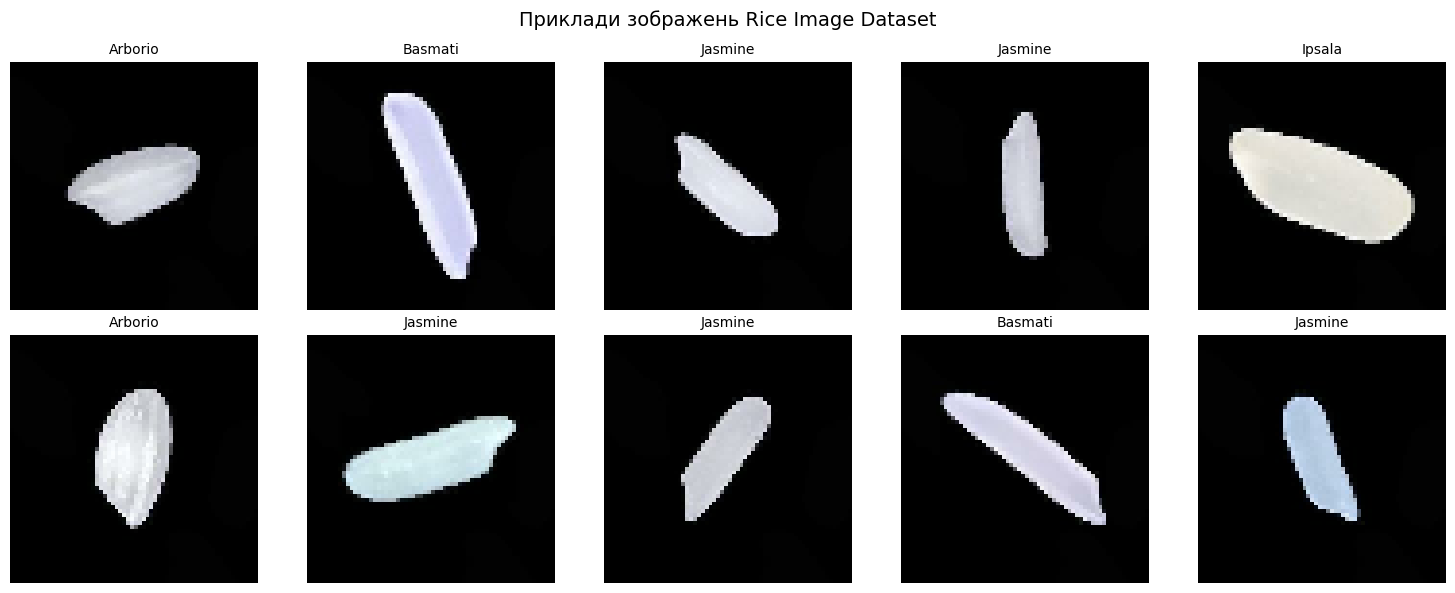

In [ ]:
images, labels = next(iter(train_ds))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(images[i].numpy())
    class_idx = np.argmax(labels[i])
    ax.set_title(CLASS_NAMES[class_idx], fontsize=10)
    ax.axis("off")
plt.suptitle("Приклади зображень Rice Image Dataset", fontsize=14)
plt.tight_layout()
plt.show()

### Базова модель з одним згортковим шаром
Побудуємо базову CNN з одним згортковим шаром: Input(64×64×3) -> Conv2D(32, 3×3, same, relu) -> MaxPooling2D(2×2) -> Flatten -> Dense(5, softmax). Модель навчається протягом 20 епох з оптимізатором Adam та функцією втрат categorical crossentropy.

In [ ]:
EPOCHS = 20

def build_base_model(filters=32, kernel_size=(3,3), padding='same', strides=(1,1)):
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(filters, kernel_size, padding=padding, strides=strides, activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

base_model = build_base_model()
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │       163,845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,741 (643.52 KB)

 Trainable params: 164,741 (643.52 KB)

 Non-trainable params: 0 (0.00 B)

### Навчання базової моделі

In [ ]:
history_base = base_model.fit(
    train_ds,
    epochs=EPOCHS, validation_data=val_ds, verbose=1
)

Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9118 - loss: 0.2686 - val_accuracy: 0.9551 - val_loss: 0.1407
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.9660 - loss: 0.1056 - val_accuracy: 0.9677 - val_loss: 0.0946
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9786 - loss: 0.0721 - val_accuracy: 0.9659 - val_loss: 0.0967
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9821 - loss: 0.0601 - val_accuracy: 0.9615 - val_loss: 0.1138
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9836 - loss: 0.0549 - val_accuracy: 0.9523 - val_loss: 0.1374
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9852 - loss: 0.0496 - val_accuracy: 0.9649 - val_loss: 0.0929
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9873 - loss: 0.0433 - val_accuracy: 0.9768 - val_loss: 0.0664
Epoch 8/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9891 - loss: 0.0376 - val_accu

Модель демонструє ознаки незначного перенавчання: train accuracy зростає до майже 1.0, тоді як val accuracy стабілізується на рівні ~0.985.

### Графіки навчання базової моделі

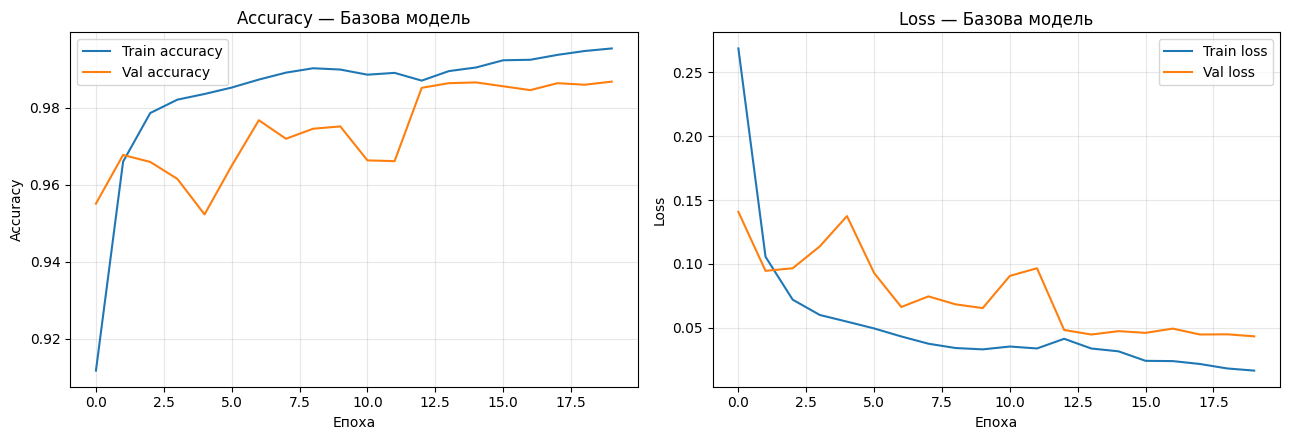

In [ ]:
def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    ax1.plot(history.history['accuracy'], label='Train accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val accuracy')
    ax1.set_xlabel('Епоха'); ax1.set_ylabel('Accuracy')
    ax1.set_title(f'Accuracy — {title}')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['loss'], label='Train loss')
    ax2.plot(history.history['val_loss'], label='Val loss')
    ax2.set_xlabel('Епоха'); ax2.set_ylabel('Loss')
    ax2.set_title(f'Loss — {title}')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_base, "Базова модель")

### Оцінка базової моделі

In [ ]:
train_loss, train_acc = base_model.evaluate(train_ds, verbose=0)
val_loss, val_acc = base_model.evaluate(val_ds, verbose=0)

print(f"Базова модель:")
print(f"  Train — loss: {train_loss:.4f}, accuracy: {train_acc:.4f}")
print(f"  Val   — loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")

Базова модель:
  Train — loss: 0.0100, accuracy: 0.9973
  Val   — loss: 0.0434, accuracy: 0.9868


### Дослідження параметрів згорткового шару

Дослідимо вплив на якість моделі:
- **padding**: 'same' vs 'valid'
- **strides**: (1,1) vs (2,2)
- **kernel_size**: (3,3), (5,5), (7,7)

#### Вплив параметра padding


padding='same'
  Train acc: 0.9968, Val acc: 0.9826

padding='valid'
  Train acc: 0.9971, Val acc: 0.9854


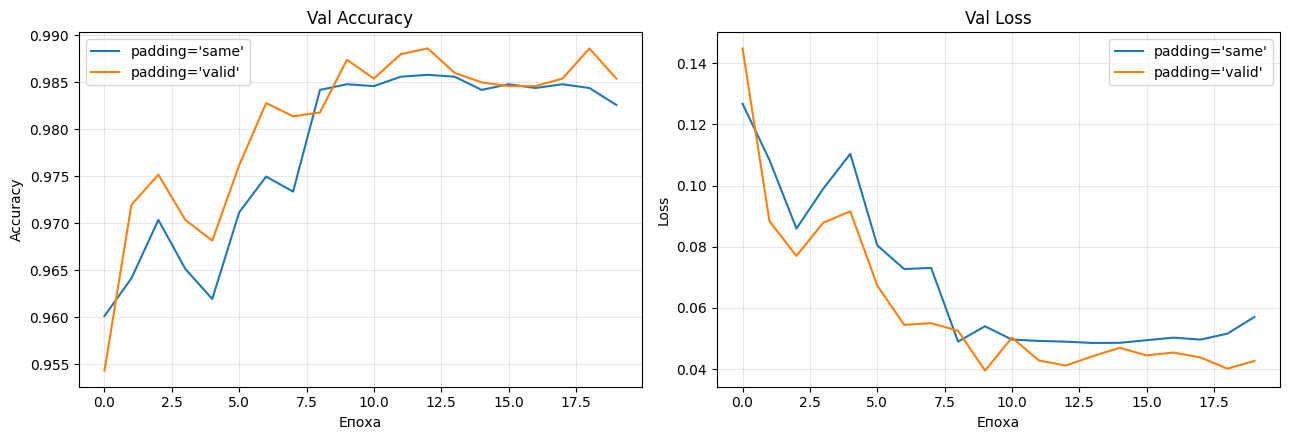

In [ ]:
results = []

for pad in ['same', 'valid']:
    print(f"\npadding='{pad}'")
    model = build_base_model(padding=pad)
    hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0)
    t_loss, t_acc = model.evaluate(train_ds, verbose=0)
    v_loss, v_acc = model.evaluate(val_ds, verbose=0)
    results.append({
        'param': 'padding', 'value': pad,
        'train_acc': t_acc, 'val_acc': v_acc,
        'train_loss': t_loss, 'val_loss': v_loss,
        'history': hist
    })
    print(f"  Train acc: {t_acc:.4f}, Val acc: {v_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for r in results:
    ax1.plot(r['history'].history['val_accuracy'], label=f"padding='{r['value']}'")
    ax2.plot(r['history'].history['val_loss'], label=f"padding='{r['value']}'")
ax1.set_title('Val Accuracy'); ax1.set_xlabel('Епоха')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title('Val Loss'); ax2.set_xlabel('Епоха')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Padding valid, який зменшує просторову розмірність, показав дещо кращий результат на цьому наборі даних.

#### Вплив параметра strides


strides=(1, 1)
  Train acc: 0.9977, Val acc: 0.9892

strides=(2, 2)
  Train acc: 0.9925, Val acc: 0.9872


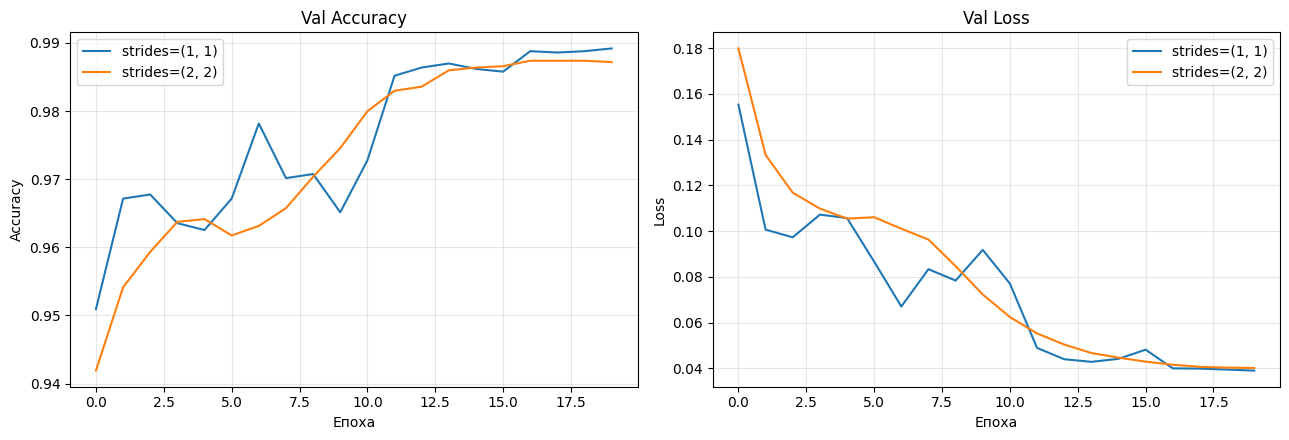

In [ ]:
for stride in [(1,1), (2,2)]:
    print(f"\nstrides={stride}")
    model = build_base_model(strides=stride)
    hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0)
    t_loss, t_acc = model.evaluate(train_ds, verbose=0)
    v_loss, v_acc = model.evaluate(val_ds, verbose=0)
    results.append({
        'param': 'strides', 'value': str(stride),
        'train_acc': t_acc, 'val_acc': v_acc,
        'train_loss': t_loss, 'val_loss': v_loss,
        'history': hist
    })
    print(f"  Train acc: {t_acc:.4f}, Val acc: {v_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for r in results:
    if r['param'] == 'strides':
        ax1.plot(r['history'].history['val_accuracy'], label=f"strides={r['value']}")
        ax2.plot(r['history'].history['val_loss'], label=f"strides={r['value']}")
ax1.set_title('Val Accuracy'); ax1.set_xlabel('Епоха')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title('Val Loss'); ax2.set_xlabel('Епоха')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Збільшений крок (2,2) показав трохи вищу val accuracy, одночасно суттєво прискоривши навчання.

#### Вплив розмірності ядра


kernel_size=(3, 3)
  Train acc: 0.9969, Val acc: 0.9888

kernel_size=(5, 5)
  Train acc: 0.9949, Val acc: 0.9808

kernel_size=(7, 7)
  Train acc: 0.9943, Val acc: 0.9792


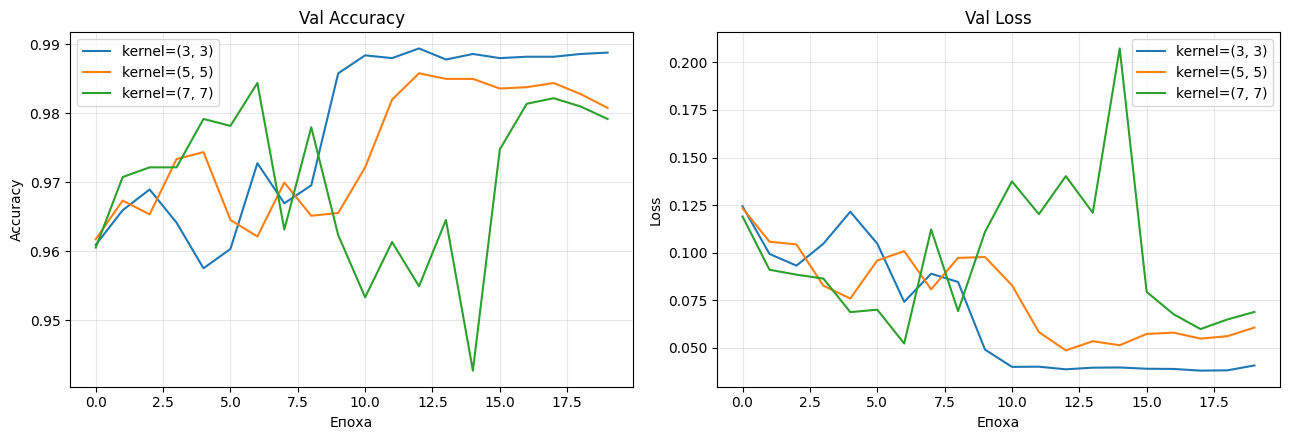

In [ ]:
for ks in [(3,3), (5,5), (7,7)]:
    print(f"\nkernel_size={ks}")
    model = build_base_model(kernel_size=ks)
    hist = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0)
    t_loss, t_acc = model.evaluate(train_ds, verbose=0)
    v_loss, v_acc = model.evaluate(val_ds, verbose=0)
    results.append({
        'param': 'kernel_size', 'value': str(ks),
        'train_acc': t_acc, 'val_acc': v_acc,
        'train_loss': t_loss, 'val_loss': v_loss,
        'history': hist
    })
    print(f"  Train acc: {t_acc:.4f}, Val acc: {v_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for r in results:
    if r['param'] == 'kernel_size':
        ax1.plot(r['history'].history['val_accuracy'], label=f"kernel={r['value']}")
        ax2.plot(r['history'].history['val_loss'], label=f"kernel={r['value']}")
ax1.set_title('Val Accuracy'); ax1.set_xlabel('Епоха')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_title('Val Loss'); ax2.set_xlabel('Епоха')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Найменше ядро 3×3 показало найкращий результат, зі збільшенням розміру ядра якість поступово знижується.

In [ ]:
import pandas as pd

rows = []
for r in results:
    rows.append({
        'Параметр': r['param'],
        'Значення': r['value'],
        'Train Accuracy': f"{r['train_acc']:.4f}",
        'Val Accuracy': f"{r['val_acc']:.4f}",
        'Train Loss': f"{r['train_loss']:.4f}",
        'Val Loss': f"{r['val_loss']:.4f}",
    })

df_results = pd.DataFrame(rows)
display(df_results)

print("\nНайкраща конфігурація за Val Accuracy по кожному параметру:")
for param in ['padding', 'strides', 'kernel_size']:
    subset = df_results[df_results['Параметр'] == param]
    best_idx = subset['Val Accuracy'].astype(float).idxmax()
    best = df_results.iloc[best_idx]
    print(f"{best['Параметр']} = {best['Значення']}, Val Accuracy = {best['Val Accuracy']}")

,Параметр,Значення,Train Accuracy,Val Accuracy,Train Loss,Val Loss
0,padding,same,0.9968,0.9826,0.0113,0.0570
1,padding,valid,0.9971,0.9854,0.0102,0.0427
2,strides,"(1, 1)",0.9977,0.9892,0.0090,0.0390
3,strides,"(2, 2)",0.9925,0.9872,0.0233,0.0402
4,kernel_size,"(3, 3)",0.9969,0.9888,0.0107,0.0407
5,kernel_size,"(5, 5)",0.9949,0.9808,0.0144,0.0606
6,kernel_size,"(7, 7)",0.9943,0.9792,0.0158,0.0688



Найкраща конфігурація за Val Accuracy по кожному параметру:
padding = valid, Val Accuracy = 0.9854
strides = (1, 1), Val Accuracy = 0.9892
kernel_size = (3, 3), Val Accuracy = 0.9888


#### Найкраща базова модель з обраними параметрами

На основі проведених експериментів обираємо найкращі значення параметрів та навчаємо фінальну базову модель.

Обрані параметри: padding='valid', strides=(2, 2), kernel_size=(3, 3)
Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8773 - loss: 0.3643 - val_accuracy: 0.9433 - val_loss: 0.1771
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9527 - loss: 0.1493 - val_accuracy: 0.9547 - val_loss: 0.1351
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9605 - loss: 0.1182 - val_accuracy: 0.9603 - val_loss: 0.1189
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9665 - loss: 0.1002 - val_accuracy: 0.9641 - val_loss: 0.1085
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9718 - loss: 0.0857 - val_accuracy: 0.9643 - val_loss: 0.1061
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9771 - loss: 0.0757 - val_accuracy: 0.9647 - val_loss: 0.1002
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9796 - loss: 0.0682 - val_accuracy: 0.9671 - val_loss: 0.0927
Epoch 8/20
234/234 ━━━━━━━━━━━━━━━

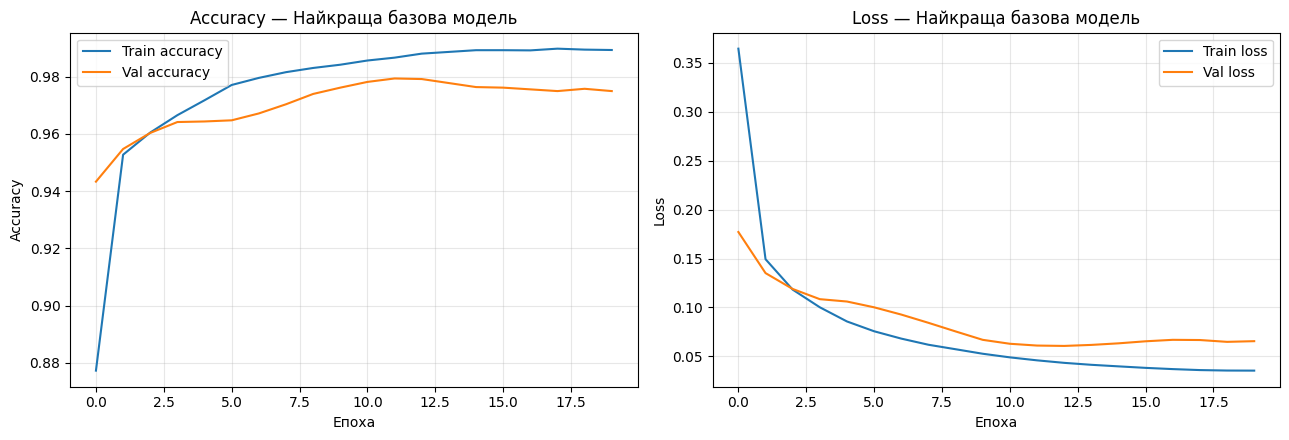


Найкраща базова модель — Val accuracy: 0.9750, Val loss: 0.0656


In [ ]:
BEST_PADDING = 'valid'
BEST_STRIDES = (2, 2)
BEST_KERNEL  = (3, 3)

print(f"Обрані параметри: padding='{BEST_PADDING}', "
      f"strides={BEST_STRIDES}, kernel_size={BEST_KERNEL}")

best_base_model = build_base_model(
    padding=BEST_PADDING, strides=BEST_STRIDES, kernel_size=BEST_KERNEL
)

history_best_base = best_base_model.fit(
    train_ds,
    epochs=EPOCHS, validation_data=val_ds, verbose=1
)

plot_history(history_best_base, "Найкраща базова модель")

v_loss, v_acc = best_base_model.evaluate(val_ds, verbose=0)
print(f"\nНайкраща базова модель — Val accuracy: {v_acc:.4f}, Val loss: {v_loss:.4f}")

Даний датасет містить зображення зерен рису здебільшого дуже світлих відтінків на чорному фоні, тому padding='valid' і strides=(2,2) не погіршили результат, для таких однорідних зображень втрата деталей при зменшенні розмірності не критична.   
Моделі легко "запам'ятати" тренувальні приклади, бо відмінностей між зображеннями всередині класу мало, а між класами - нюанси форми та відтінку, тому у моделі є перенавчання, але незначне.

## Альтернативні архітектури CNN

In [ ]:
from sklearn.metrics import classification_report
from tensorflow.keras.metrics import AUC


def compile_model(model):
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            AUC(name='auc', multi_label=False)
        ]
    )
    return model

# Модель A: 2 Conv-блоки (без BN, без Dropout)
def build_model_A():
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='ModelA_2conv')
    return compile_model(model)

# Модель B: 3 Conv-блоки + BatchNormalization
def build_model_B():
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Flatten(),
        Dense(256, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='ModelB_3conv_BN')
    return compile_model(model)

# Модель C: 2 Conv-блоки + BN + Dropout
def build_model_C():
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='ModelC_2conv_BN_Drop')
    return compile_model(model)

# Модель D: 3 Conv-блоки + BN + Dropout (найглибша)
def build_model_D():
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.2),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(0.2),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='ModelD_3conv_BN_Drop')
    return compile_model(model)


In [ ]:

#  Навчання всіх моделей
architectures = {
    'A: 2Conv':          build_model_A,
    'B: 3Conv+BN':       build_model_B,
    'C: 2Conv+BN+Drop':  build_model_C,
    'D: 3Conv+BN+Drop':  build_model_D,
}

arch_histories = {}
arch_metrics   = {}


In [ ]:
def get_metric(d, prefix):
    for k, v in d.items():
        if k == prefix or k.startswith(prefix):
            return v
    raise KeyError(f"Метрику '{prefix}' не знайдено серед: {list(d.keys())}")

arch_histories = {}
arch_metrics   = {}

for name, builder in architectures.items():
    print(f"\n{'='*55}\nНавчання: {name}\n{'='*55}")
    m = builder()
    hist = m.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_ds,
        verbose=1
    )
    arch_histories[name] = hist

    metrics_dict = m.evaluate(
        val_ds,
        verbose=0,
        return_dict=True
    )

    acc = get_metric(metrics_dict, 'accuracy')
    p   = get_metric(metrics_dict, 'precision')
    r   = get_metric(metrics_dict, 'recall')
    auc = get_metric(metrics_dict, 'auc')
    f1  = 2 * p * r / (p + r + 1e-8)

    arch_metrics[name] = {
        'accuracy': acc, 'precision': p,
        'recall': r, 'auc': auc, 'f1': f1
    }

    print(f"  Val accuracy : {acc:.4f}")
    print(f"  Val precision: {p:.4f}  recall: {r:.4f}  F1: {f1:.4f}")
    print(f"  Val AUC      : {auc:.4f}")


Навчання: A: 2Conv
Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.9269 - auc: 0.9926 - loss: 0.2205 - precision: 0.9452 - recall: 0.9092 - val_accuracy: 0.9700 - val_auc: 0.9985 - val_loss: 0.0886 - val_precision: 0.9701 - val_recall: 0.9700
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.9685 - auc: 0.9982 - loss: 0.0897 - precision: 0.9687 - recall: 0.9682 - val_accuracy: 0.9736 - val_auc: 0.9987 - val_loss: 0.0784 - val_precision: 0.9738 - val_recall: 0.9736
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.9768 - auc: 0.9990 - loss: 0.0687 - precision: 0.9770 - recall: 0.9766 - val_accuracy: 0.9679 - val_auc: 0.9982 - val_loss: 0.0894 - val_precision: 0.9683 - val_recall: 0.9679
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.9822 - auc: 0.9992 - loss: 0.0527 - precision: 0.9822 - recall: 0.9822 - val_accuracy: 0.9722 - val_auc: 0.9988 - val_loss: 0.0748 - val_precision: 0.9721 - val_recall: 0.9720
Epoc

,Модель,Accuracy,Precision,Recall,F1,AUC
0,A: 2Conv,0.9850,0.9850,0.9850,0.9850,0.9980
1,B: 3Conv+BN,0.9920,0.9920,0.9920,0.9920,0.9985
2,C: 2Conv+BN+Drop,0.7921,0.7921,0.7921,0.7921,0.9261
3,D: 3Conv+BN+Drop,0.9856,0.9856,0.9856,0.9856,0.9971


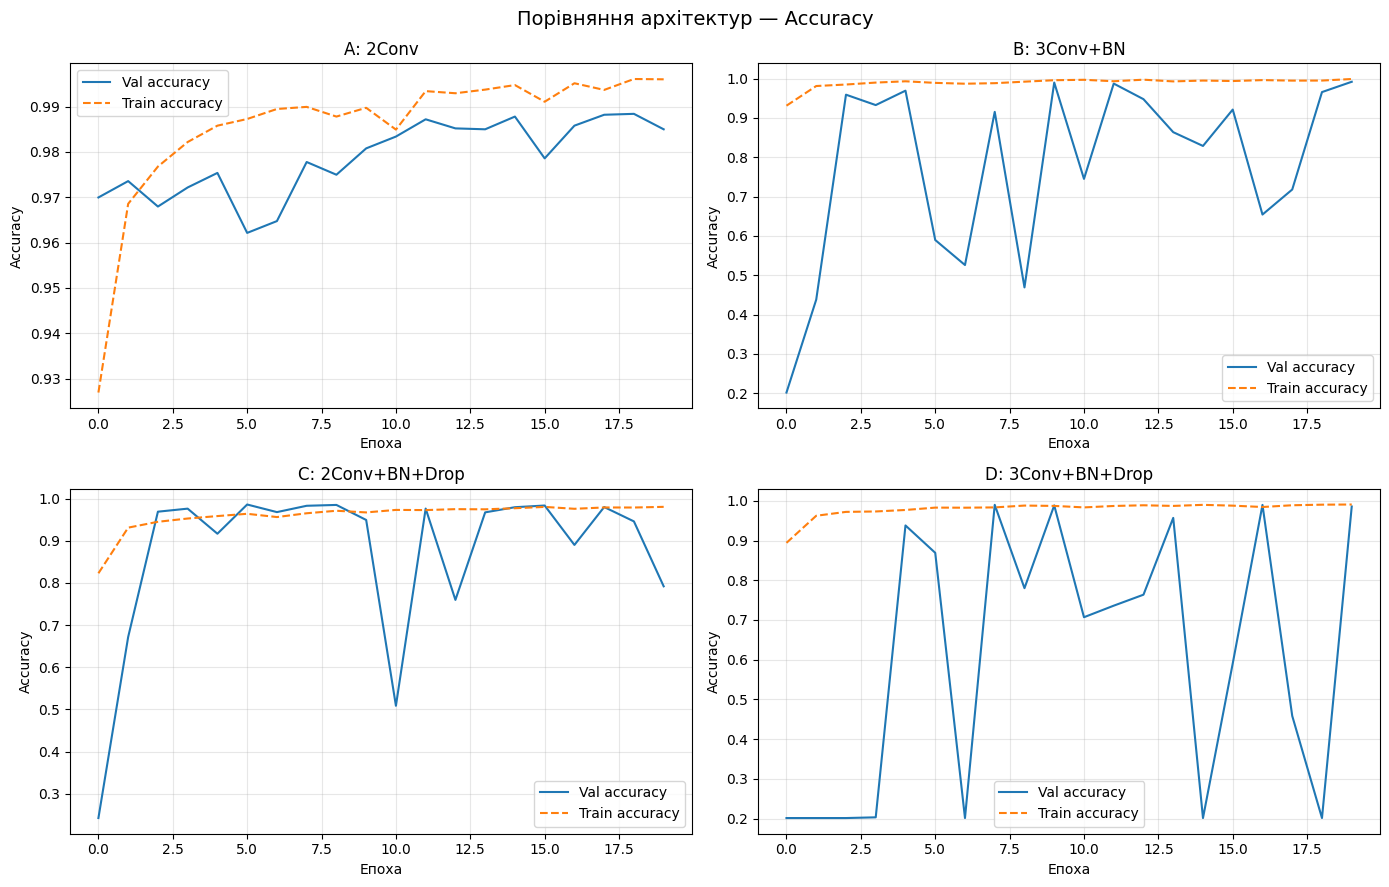


Найкраща архітектура (за AUC): B: 3Conv+BN
  AUC      : 0.9985
  Accuracy : 0.9920


In [ ]:
rows = []
for name, m in arch_metrics.items():
    rows.append({
        'Модель':    name,
        'Accuracy':  f"{m['accuracy']:.4f}",
        'Precision': f"{m['precision']:.4f}",
        'Recall':    f"{m['recall']:.4f}",
        'F1':        f"{m['f1']:.4f}",
        'AUC':       f"{m['auc']:.4f}",
    })

df_arch = pd.DataFrame(rows)
display(df_arch)

# Графіки для всіх архітектур
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (name, hist) in enumerate(arch_histories.items()):
    ax = axes[i]
    ax.plot(hist.history['val_accuracy'], label='Val accuracy')
    ax.plot(hist.history['accuracy'],     label='Train accuracy', linestyle='--')
    ax.set_title(name); ax.set_xlabel('Епоха'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Порівняння архітектур — Accuracy', fontsize=14)
plt.tight_layout()
plt.show()

best_arch_name = max(arch_metrics, key=lambda n: arch_metrics[n]['auc'])
print(f"\nНайкраща архітектура (за AUC): {best_arch_name}")
print(f"  AUC      : {arch_metrics[best_arch_name]['auc']:.4f}")
print(f"  Accuracy : {arch_metrics[best_arch_name]['accuracy']:.4f}")

Модель B (3Conv+BN) виявилася найкращою. Тепер дослідимо регуляризації (dropout, early stopping, ініціалізація ваг)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

BEST_BUILDER = architectures[best_arch_name]  # B: 3Conv+BN
reg_results  = {}

# Dropout rate
def build_with_dropout(rate):
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(rate),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Dropout(rate),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(min(rate * 2, 0.5)),
        Dense(NUM_CLASSES, activation='softmax')
    ], name=f'Dropout_{rate}')
    return compile_model(model)

for rate in [0.1, 0.25, 0.4]:
    print(f"\nDropout rate = {rate}")
    m = build_with_dropout(rate)
    hist = m.fit(
        train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0
    )
    metrics_dict = m.evaluate(val_ds, verbose=0, return_dict=True)
    val_acc = get_metric(metrics_dict, 'accuracy')
    reg_results[f'Dropout={rate}'] = {'history': hist, 'val_acc': val_acc}
    print(f"  Val accuracy: {val_acc:.4f}")

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss', patience=4,
    restore_best_weights=True, verbose=1
)

print("\nНавчання з EarlyStopping")
m_es = BEST_BUILDER()
hist_es = m_es.fit(
    train_ds, epochs=50,
    validation_data=val_ds,
    callbacks=[early_stop], verbose=1
)
metrics_dict = m_es.evaluate(val_ds, verbose=0, return_dict=True)
val_acc_es = get_metric(metrics_dict, 'accuracy')
reg_results['EarlyStopping'] = {'history': hist_es, 'val_acc': val_acc_es}
print(f"  Val acc: {val_acc_es:.4f}")

# Ініціалізація ваг
def build_with_init(initializer_name):
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Conv2D(32, (3,3), padding='same', activation='relu',
               kernel_initializer=initializer_name),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), padding='same', activation='relu',
               kernel_initializer=initializer_name),
        BatchNormalization(),
        MaxPooling2D(2,2),
        Conv2D(128, (3,3), padding='same', activation='relu',
               kernel_initializer=initializer_name),
        BatchNormalization(),
        Flatten(),
        Dense(256, activation='relu', kernel_initializer=initializer_name),
        Dense(NUM_CLASSES, activation='softmax')
    ], name=f'Init_{initializer_name}')
    return compile_model(model)

for init in ['glorot_uniform', 'he_normal', 'random_normal']:
    print(f"\nInitializer: {init}")
    m = build_with_init(init)
    hist = m.fit(
        train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=0
    )
    metrics_dict = m.evaluate(val_ds, verbose=0, return_dict=True)
    val_acc = get_metric(metrics_dict, 'accuracy')
    reg_results[f'Init={init}'] = {'history': hist, 'val_acc': val_acc}
    print(f"  Val accuracy: {val_acc:.4f}")

# Підсумкова таблиця
reg_rows = [{'Варіант': k, 'Val Accuracy': f"{v['val_acc']:.4f}"}
            for k, v in reg_results.items()]
display(pd.DataFrame(reg_rows))


Dropout rate = 0.1
  Val accuracy: 0.5431

Dropout rate = 0.25
  Val accuracy: 0.4367

Dropout rate = 0.4
  Val accuracy: 0.9798

Навчання з EarlyStopping
Epoch 1/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 51s 202ms/step - accuracy: 0.9314 - auc: 0.9852 - loss: 0.4296 - precision: 0.9342 - recall: 0.9300 - val_accuracy: 0.2015 - val_auc: 0.5021 - val_loss: 31.0384 - val_precision: 0.2015 - val_recall: 0.2015
Epoch 2/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 46s 198ms/step - accuracy: 0.9807 - auc: 0.9984 - loss: 0.0616 - precision: 0.9807 - recall: 0.9807 - val_accuracy: 0.5867 - val_auc: 0.7865 - val_loss: 4.1069 - val_precision: 0.5874 - val_recall: 0.5863
Epoch 3/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 47s 200ms/step - accuracy: 0.9827 - auc: 0.9986 - loss: 0.0592 - precision: 0.9827 - recall: 0.9827 - val_accuracy: 0.8045 - val_auc: 0.9435 - val_loss: 0.8797 - val_precision: 0.8052 - val_recall: 0.8039
Epoch 4/50
234/234 ━━━━━━━━━━━━━━━━━━━━ 46s 198ms/step - accuracy: 0.9888 - auc: 0.9992 - loss: 0.0347 - pre

,Варіант,Val Accuracy
0,Dropout=0.1,0.5431
1,Dropout=0.25,0.4367
2,Dropout=0.4,0.9798
3,EarlyStopping,0.9754
4,Init=glorot_uniform,0.9663
5,Init=he_normal,0.9229
6,Init=random_normal,0.6552


Дослідження впливу регуляризації проводилось на базі найкращої архітектури B (3Conv+BN). Результати показали наступне.
Додавання дропауту дало неоднозначні результати: при rate=0.1 та rate=0.25 модель показала низьку точність (0.54 та 0.44 відповідно) через нестабільність навчання у поєднанні з BatchNormalization, тоді як rate=0.4 дав прийнятний результат — 0.9798. Загалом, дропаут у поєднанні з BN може заважати навчанню, оскільки ці два методи по-різному впливають на розподіл активацій.
Рання зупинка навчання (EarlyStopping з patience=4) зупинила навчання на 9-й епосі з 50, відновивши ваги з 5-ї епохи. Val accuracy склала 0.9754, що є гіршим результатом порівняно з повним навчанням (0.9920). Це свідчить про те, що модель потребує більше епох для стабілізації.
Ініціалізація ваг суттєво вплинула на результат: glorot_uniform дав найкращий результат (0.9663), he_normal — 0.9229, random_normal — лише 0.6552. Glorot підходить краще, оскільки він розроблений для активацій типу ReLU з урахуванням розміру шарів, тоді як random_normal без масштабування призводить до нестабільного навчання.

##  Візуалізація процесу навчання за допомогою TensorBoard

Cтворення логів для вже навчених моделей

In [ ]:
import subprocess
subprocess.run(['pip', 'install', '--upgrade', 'setuptools', 'tensorboard', '--quiet'])

CompletedProcess(args=['pip', 'install', '--upgrade', 'setuptools', 'tensorboard', '--quiet'], returncode=0)

In [ ]:
import datetime

LOG_DIR = "./logs"

# Функція для запису метрик в TensorBoard
def log_history_to_tensorboard(history, name):
    log_path = os.path.join(LOG_DIR, name)
    writer = tf.summary.create_file_writer(log_path)
    with writer.as_default():
        for epoch, (acc, val_acc, loss, val_loss) in enumerate(zip(
            history.history['accuracy'],
            history.history['val_accuracy'],
            history.history['loss'],
            history.history['val_loss']
        )):
            tf.summary.scalar('accuracy/train', acc,   step=epoch)
            tf.summary.scalar('accuracy/val',   val_acc, step=epoch)
            tf.summary.scalar('loss/train',     loss,    step=epoch)
            tf.summary.scalar('loss/val',       val_loss, step=epoch)
    writer.flush()
    print(f"  Збережено: {log_path}")

print("Запис логів у TensorBoard...")

# Базова модель
log_history_to_tensorboard(history_base, "base_model")

# Найкраща базова модель
log_history_to_tensorboard(history_best_base, "best_base_model")

# Архітектури A, B, C, D
for name, hist in arch_histories.items():
    safe_name = name.replace(": ", "_").replace("+", "_")
    log_history_to_tensorboard(hist, f"arch_{safe_name}")

# Регуляризація
for name, data in reg_results.items():
    safe_name = name.replace("=", "_").replace(".", "_")
    log_history_to_tensorboard(data['history'], f"reg_{safe_name}")

print("\nВсі логи збережено!")


Запис логів у TensorBoard...
  Збережено: ./logs\base_model
  Збережено: ./logs\best_base_model
  Збережено: ./logs\arch_A_2Conv
  Збережено: ./logs\arch_B_3Conv_BN
  Збережено: ./logs\arch_C_2Conv_BN_Drop
  Збережено: ./logs\arch_D_3Conv_BN_Drop
  Збережено: ./logs\reg_Dropout_0_1
  Збережено: ./logs\reg_Dropout_0_25
  Збережено: ./logs\reg_Dropout_0_4
  Збережено: ./logs\reg_EarlyStopping
  Збережено: ./logs\reg_Init_glorot_uniform
  Збережено: ./logs\reg_Init_he_normal
  Збережено: ./logs\reg_Init_random_normal

Всі логи збережено!


In [ ]:
%reload_ext tensorboard
%tensorboard --logdir ./logs

ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Zlata\OneDrive\Documents\GitHub\icppr\icppr\.venv\Scripts\tensorboard.exe\__main__.py", line 2, in <module>
    from tensorboard.main import run_main
  File "c:\Users\Zlata\OneDrive\Documents\GitHub\icppr\icppr\.venv\Lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "c:\Users\Zlata\OneDrive\Documents\GitHub\icppr\icppr\.venv\Lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'